In [87]:
import numpy as np  
import matplotlib.pyplot as plt

In [88]:

def Nelden_Mead(fct, simplex, diam_tol = 1e-3, max_eval = 250, iteration=False, method=None):
    # parameters
    de = 2
    doc = 0.5
    dic = 0.5
    gamma = 0.5
    
    # evaluate simplex
    f = np.array([fct(s) for s in simplex])
    # dimension
    n = len(simplex[0])
    neval = len(f)

    
    while neval <= max_eval:
# 1) SORTING
        # Sort simplex [y0,...,yn]
        idx = np.argsort(f)
        simplex = simplex[idx]
        # Sort f(simplex)
        f = f[idx]
        fbest = f[0]

# Validation du diameter approché 
        diam = max(np.linalg.norm(simplex[0]-simplex[j]) for j in range(n+1))
        if diam < diam_tol:
            if method != "simple":
                print(f"Stopped because diameter: {diam:.4e} < {diam_tol:.4e}")
            break

        xc = 1/n * np.sum(simplex[:-1], axis=0)
# 2) Reflect
        xr = xc + (xc - simplex[-1])
        fr = fct(xr)
        
        if fbest <= fr < f[-2]:
            simplex[-1] = xr
            f[-1] = fr
            neval += 1
            continue 

# 3) Expand
        if fr < fbest:
            xe = xc + de*(xc-simplex[-1])
            fe = fct(xe)
            if fe < fr:
                simplex[-1] = xe
                f[-1] = fe
                neval += 1
            else:
                simplex[-1] = xr
                f[-1] = fr
                neval += 1
            continue

# 4) outside contraction
        if f[-2] <= fr < f[-1]:
            xoc = xc + doc*(xc-simplex[-1])
            foc = fct(xoc)
            if foc < fr:
                simplex[-1] = xoc
                f[-1] = foc
                neval += 1
            else:
                simplex[-1] = xr
                f[-1] = fr
                neval += 1
            continue
        
# 5) inside contraction
        if fr >= f[-1]:
            xic = xc - dic*(xc-simplex[-1])
            fic = fct(xic)
            if fic < f[-1]:
                simplex[-1] = xic
                f[-1] = fic
                neval += 1
                continue
# 6) Shrink
        for i in range(1, n+1):
            simplex[i] = simplex[0] + gamma*(simplex[i]-simplex[0])
            f[i] = fct(simplex[i])
            # Add all evaluations for the shrink step
            neval += 1
    if method != "simple":    
        print(f"NM reached {neval} function evaluations")
    if iteration:
        return f, simplex, neval
    return f, simplex

a)

Stopped because diameter: 9.1288e-04 < 1.0000e-03
NM reached 44 function evaluations


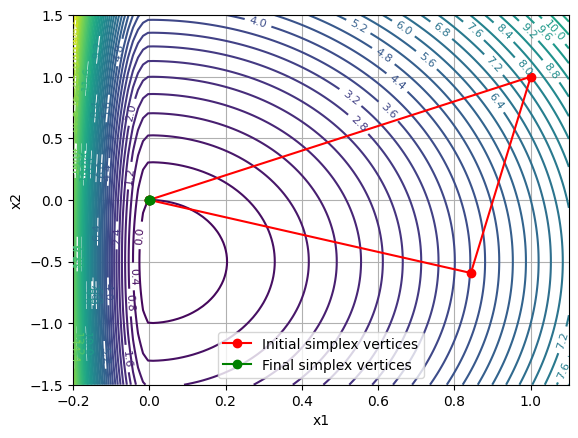

In [89]:
def McKinnon_fct(x):
    x1, x2 = x
    if x1 <= 0:
        return 360*x1**2 + x2**2 + x2
    else:
        return 6*x1**2 + x2**2 + x2
    
def McKinnon_fct_np(X1, X2):
    return np.where(X1 <= 0, 360*X1**2 + X2 + X2**2, 6*X1**2 + X2 + X2**2)

Lambda = (1+np.sqrt(33)) / 8
Mu = (1-np.sqrt(33)) / 8

Initial_McKinnon_simplex = np.array([[0,0], [Lambda, Mu], [1,1]])
f, simplex = Nelden_Mead(McKinnon_fct, Initial_McKinnon_simplex)

plt.figure()
x1 = np.linspace(-0.2, 1.1, 100)
x2 = np.linspace(-1.5, 1.5, 100)
X1, X2 = np.meshgrid(x1,x2)
contours = plt.contour(X1, X2, McKinnon_fct_np(X1, X2), levels=50)
#--------------------------------------------
Initial_McKinnon_simplex = np.vstack([Initial_McKinnon_simplex, Initial_McKinnon_simplex[0]])
simplex = np.vstack([simplex, simplex[0]])
plt.plot(Initial_McKinnon_simplex[:,0], Initial_McKinnon_simplex[:,1], color='red', marker='o', label='Initial simplex vertices')
plt.plot(simplex[:,0], simplex[:,1], color='green', marker='o', label='Final simplex vertices')
#--------------------------------------------
plt.clabel(contours, inline=True, fontsize=8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.xticks()
plt.yticks()
plt.show()

b)

In [90]:
def pts_generator_unit_cercle(center, rayon=1, size=3):
    h, k = center
    x = np.random.uniform(h-rayon, h+rayon, size=size)

    pts = np.zeros((size,2))
    for i in range(len(x)):
        sign = np.random.default_rng().choice([-1, 1])
        pts[i,0] = x[i]
        pts[i,1] = sign*np.sqrt(rayon**2 - (x[i]-h)**2) + k
    return pts


Centre = [[1,1],[10,5]]
iterations = 20

conv_values = []
conv_x1 = []
conv_x2 = []
nbre_eval = []
conv_diam = []

for p in range(iterations):
    pts = pts_generator_unit_cercle(Centre[0], size=3)
    fct, simplex, neval = Nelden_Mead(McKinnon_fct, pts, iteration=True, method="simple")
    conv_values.append(np.mean(fct[0]))
    conv_x1.append(np.mean(simplex[0,0]))
    conv_x2.append(np.mean(simplex[0,1]))
    nbre_eval.append(neval)
    conv_diam.append(max(np.linalg.norm(simplex[0]-simplex[j]) for j in range(len(simplex))))
print("---------------------------------------------")
print(f"En moyenne NM a atteint une valeur de {np.mean(conv_values):.3e} au point ({np.mean(conv_x1):.3e}, {np.mean(conv_x2):.3e}) en {np.mean(nbre_eval):.2f} évaluations de la fonction")
print("---------------------------------------------")
# print(conv_values)

float_format="{:.5e}"

print("\\hline")
for r in range(len(conv_values)):
    row_str = " & ".join(val for val in ["{:.3e}".format(conv_values[r]), "{:.3e}".format(conv_x1[r]), "{:.3e}".format(conv_x2[r]), str(nbre_eval[r]),"{:.3e}".format(conv_diam[r])])
    print(row_str + " \\\\ \\hline")

print("\\hline")
print("\\end{tabular}")



if False:
    #------------------- PLOT -------------------
    plt.figure()
    x1 = np.linspace(-0.2, 1.1, 100)
    x2 = np.linspace(-1.5, 1.5, 100)
    X1, X2 = np.meshgrid(x1,x2)
    contours = plt.contour(X1, X2, McKinnon_fct_np(X1, X2), levels=50)
    #--------------------------------------------
    pts = np.vstack([pts, pts[0]])
    simplex = np.vstack([simplex, simplex[0]])
    plt.plot(simplex[:,0], simplex[:,1], color='red', label='Simplex vertices')
    plt.plot(pts[:,0], pts[:,1], color='blue', label='Initial points')
    #--------------------------------------------
    plt.clabel(contours, inline=True, fontsize=8)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    plt.xticks()
    plt.yticks()
    plt.show()

---------------------------------------------
En moyenne NM a atteint une valeur de -2.500e-01 au point (1.747e-04, -4.998e-01) en 39.65 évaluations de la fonction
---------------------------------------------
\hline
-2.500e-01 & 2.343e-04 & -5.001e-01 & 39 & 8.348e-04 \\ \hline
-2.500e-01 & 3.355e-04 & -5.002e-01 & 47 & 6.501e-04 \\ \hline
-2.500e-01 & 1.365e-04 & -5.005e-01 & 47 & 5.947e-04 \\ \hline
-2.500e-01 & 3.756e-05 & -5.004e-01 & 42 & 8.473e-04 \\ \hline
-2.500e-01 & 7.254e-05 & -4.994e-01 & 39 & 7.457e-04 \\ \hline
-2.500e-01 & -4.986e-06 & -4.997e-01 & 49 & 4.805e-04 \\ \hline
-2.500e-01 & 2.809e-04 & -4.995e-01 & 37 & 8.134e-04 \\ \hline
-2.500e-01 & 1.188e-04 & -5.002e-01 & 44 & 8.249e-04 \\ \hline
-2.500e-01 & 1.627e-04 & -5.004e-01 & 33 & 9.433e-04 \\ \hline
-2.500e-01 & 1.537e-04 & -4.996e-01 & 37 & 7.833e-04 \\ \hline
-2.500e-01 & 2.188e-04 & -4.999e-01 & 38 & 6.862e-04 \\ \hline
-2.500e-01 & 5.254e-04 & -4.989e-01 & 35 & 9.785e-04 \\ \hline
-2.500e-01 & 1.761e-04 & -

c)

In [91]:
conv_values = []
conv_x1 = []
conv_x2 = []
nbre_eval = []

for p in range(iterations):
    pts = pts_generator_unit_cercle(Centre[1], size=3)
    fct, simplex, neval = Nelden_Mead(McKinnon_fct, pts, iteration=True,method="simple")
    conv_values.append(np.mean(fct))
    conv_x1.append(np.mean(simplex[0,0]))
    conv_x2.append(np.mean(simplex[0,1]))
    nbre_eval.append(neval)
print("---------------------------------------------")
print(f"En moyenne NM a atteint une valeur de {np.mean(conv_values):.3e} au point ({np.mean(conv_x1):.3e}, {np.mean(conv_x2):.3e}) en {np.mean(nbre_eval):.2f} évaluations de la fonction")
print("---------------------------------------------")

print("\\hline")
for r in range(len(conv_values)):
    row_str = " & ".join(val for val in ["{:.3e}".format(conv_values[r]), "{:.3e}".format(conv_x1[r]), "{:.3e}".format(conv_x2[r]), str(nbre_eval[r]),"{:.3e}".format(conv_diam[r])])
    print(row_str + " \\\\ \\hline")

print("\\hline")
print("\\end{tabular}")

---------------------------------------------
En moyenne NM a atteint une valeur de -2.500e-01 au point (9.524e-05, -5.000e-01) en 59.65 évaluations de la fonction
---------------------------------------------
\hline
-2.500e-01 & 7.558e-05 & -5.001e-01 & 52 & 8.348e-04 \\ \hline
-2.500e-01 & -1.649e-05 & -5.005e-01 & 57 & 6.501e-04 \\ \hline
-2.500e-01 & 2.507e-04 & -5.000e-01 & 55 & 5.947e-04 \\ \hline
-2.500e-01 & 1.629e-04 & -4.996e-01 & 97 & 8.473e-04 \\ \hline
-2.500e-01 & 9.993e-05 & -4.993e-01 & 46 & 7.457e-04 \\ \hline
-2.500e-01 & 6.878e-05 & -4.995e-01 & 62 & 4.805e-04 \\ \hline
-2.500e-01 & 5.639e-05 & -4.995e-01 & 51 & 8.134e-04 \\ \hline
-2.500e-01 & 3.471e-05 & -5.001e-01 & 57 & 8.249e-04 \\ \hline
-2.500e-01 & 6.897e-05 & -5.000e-01 & 59 & 9.433e-04 \\ \hline
-2.500e-01 & 5.857e-05 & -4.994e-01 & 68 & 7.833e-04 \\ \hline
-2.500e-01 & 5.681e-05 & -5.002e-01 & 64 & 6.862e-04 \\ \hline
-2.500e-01 & 2.061e-04 & -5.002e-01 & 49 & 9.785e-04 \\ \hline
-2.500e-01 & 1.539e-04 & -